--- Dataset Shape ---
(150, 5)

--- First 5 Rows ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


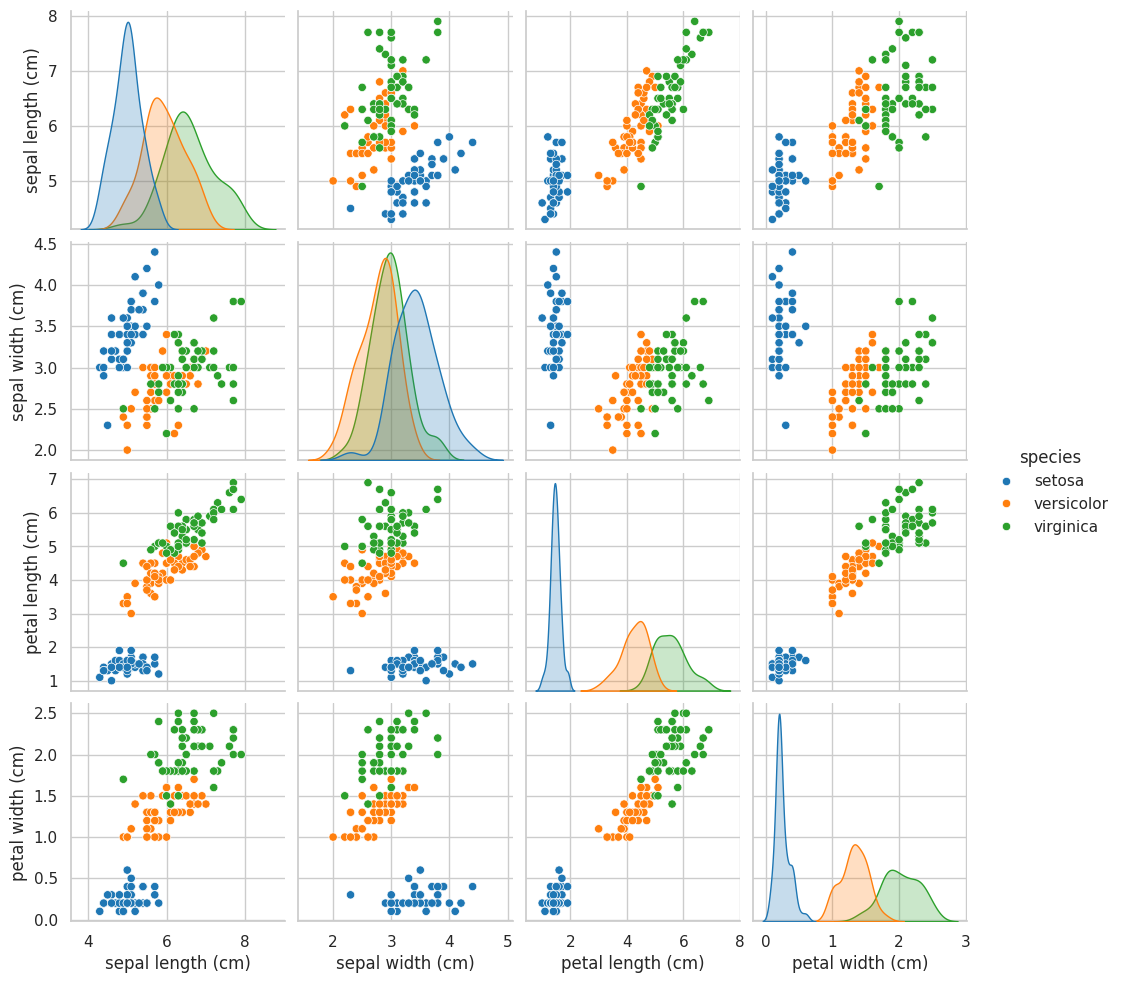


================ EVALUATION SUMMARY ================
Logistic Regression Accuracy: 93.33%
Random Forest Accuracy:       90.00%

--- Classification Report (Random Forest) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



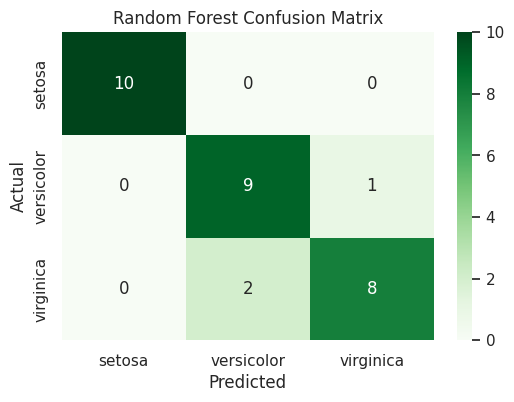

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Dataset
iris_raw = load_iris()
df = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)
df['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)

print("--- Dataset Shape ---")
print(df.shape)
print("\n--- First 5 Rows ---")
print(df.head())

# 2. EDA Visualizations
sns.set_theme(style="whitegrid")
pairplot_fig = sns.pairplot(df, hue='species', diag_kind='kde', palette='tab10')
plt.show()

# 3. Train/Test Split & Scaling
X = df[iris_raw.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Models
# Logistic Regression
log_reg = LogisticRegression(max_iter=200, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("\n================ EVALUATION SUMMARY ================")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")
print(f"Random Forest Accuracy:       {accuracy_score(y_test, y_pred_rf) * 100:.2f}%\n")

print("--- Classification Report (Random Forest) ---")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=iris_raw.target_names, yticklabels=iris_raw.target_names, ax=ax)
ax.set_title("Random Forest Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.show()